## LULC Temporal Stability

We can't do this yet because we only have 2 time points of LULC. I could run a single tile for all years as a test. This is a plan to assess temporal stability across LULC outputs.

For each tile:
1. Load all LULC assets for the 2000-2025 time range
2. Flip rate: count how many times each pixel changes. Flag pixels over a threshhold.
3. Reversals/Flicker: Count A→B→A patterns within 1–3 years, such as Tree→Grassland→Tree. These are almost always classification noise rather than real change, which makes this the most diagnostic single metric. Flag flickering pixels and note which classes over which years.
4. Implausible transitions. Build an annual transition matrix and flag transitions that are unlikely within one year, such as Built-up→Tree cover, Water→Built-up outside known reclamation, or Mangrove↔Cropland. Report their share of all change.
5. Temporal stability. For each pixel, record the percentage of years matching its modal class and the number of distinct classes it takes over 26 years. Map these to find unstable hotspots, which typically fall in coastal mixed pixels, cloud-prone areas and grass/shrub boundaries.
6. Class area time series. Plot annual area per class. Year-to-year jumps that coincide with input changes are artefacts, not land change. Common causes are Landsat 5→7→8/9 sensor transitions, Landsat 7 SLC-off gaps after 2003, and years with low clear-observation counts in the GeoMAD.
7. Invariant areas. Areas known to be stable, such as protected forest or old urban cores, should show close to zero change.

TODO: What do do if we see bad temporal stability for many pixels, especially for certain classes.

In [ ]:
# TODO: Run all LULC for this tile.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from odc.stac import load
from pystac import Item
from rustac import search_sync

from ldn.aws import configure_s3_access_profile
from ldn.typology import classes, classes_flipped
from ldn.utils import (
    LULC_DATASET_ID,
    SENSOR,
    dataset_prefix,
)

configure_s3_access_profile()

In [14]:
LULC_PARQUET = "https://dep-public-staging.s3.us-west-2.amazonaws.com/dep_ls_lulc/0-0-9/dep_ls_lulc.parquet"
OWNER = "dep"
TILES = [(63, 20)]  # SW Viti Levu, Fiji
YEARS = range(2000, 2026)
NODATA = 255

FLIP_THRESHOLD = 4  # flag pixels with more than this many year-to-year changes
FLICKER_MAX_YEARS = 3  # A -> B -> A where B lasts at most this many years
MODAL_THRESHOLD = 0.8  # flag pixels whose modal class covers less than this share of years
DISTINCT_THRESHOLD = 3  # flag pixels with more than this many distinct classes

# Transitions that are unlikely within one year
IMPLAUSIBLE = [
    (classes["Built-up"], classes[label]) for label in ["Tree cover", "Grassland", "Cropland", "Wetland", "Water"]
] + [
    (classes["Water"], classes["Built-up"]),
    (classes["Wetland"], classes["Cropland"]),
    (classes["Cropland"], classes["Wetland"]),
]

In [17]:
def load_tile(x: int, y: int):
    """Load the annual LULC classification for one tile as a (time, y, x) DataArray."""
    name = dataset_prefix(OWNER, SENSOR, LULC_DATASET_ID)
    ids = [f"{name}_{x:03}_{y:03}_{year}" for year in YEARS]
    docs = search_sync(LULC_PARQUET, ids=ids)
    items = [Item.from_dict(doc) for doc in docs]
    # TODO: Reenable the check for missing items once the data is complete.
    # if len(items) != len(ids):
    #     raise ValueError(f"Found {len(items)} of {len(ids)} items for tile {x:03}_{y:03}")
    return load(items, measurements=["classification"], chunks={})["classification"].load()


def flag_pixels(a: np.ndarray) -> dict:
    """Flag temporally unstable pixels for each test.

    Args:
        a: Class array of shape (time, y, x).

    Returns:
        Dict of boolean (y, x) arrays: "valid" plus one per test. Pixels with nodata in any year are
        not valid and are never flagged.
    """
    n_years = len(a)
    valid = (a != NODATA).all(axis=0)
    changes = a[1:] != a[:-1]

    flicker = np.zeros(valid.shape, bool)
    for lag in range(2, FLICKER_MAX_YEARS + 2):
        flicker |= ((a[:-lag] == a[lag:]) & changes[: n_years - lag]).any(axis=0)

    implausible = np.zeros((256, 256), bool)
    for src, dst in IMPLAUSIBLE:
        implausible[src, dst] = True

    counts = np.stack([(a == c).sum(axis=0) for c in classes_flipped if c != NODATA])

    flags = {
        "flip_rate": changes.sum(axis=0) > FLIP_THRESHOLD,
        "flicker": flicker,
        "implausible": implausible[a[:-1], a[1:]].any(axis=0),
        "low_modal_share": counts.max(axis=0) / n_years < MODAL_THRESHOLD,
        "many_classes": (counts > 0).sum(axis=0) > DISTINCT_THRESHOLD,
    }
    flags = {k: v & valid for k, v in flags.items()}
    flags["any"] = np.logical_or.reduce(list(flags.values()))
    flags["valid"] = valid
    return flags

In [ ]:
rows = {}
flags_by_tile = {}
areas_by_tile = {}  # TODO: 3832 is not an equal area crs.

for x, y in TILES:
    lulc = load_tile(x, y)
    flags = flag_pixels(lulc.values)
    flags_by_tile[(x, y)] = flags
    rows[f"{x:03}_{y:03}"] = {k: int(v.sum()) for k, v in flags.items()}

    res = lulc.odc.geobox.resolution
    pixel_km2 = abs(res.x * res.y) / 1e6
    areas_by_tile[(x, y)] = pd.DataFrame(
        {
            classes_flipped[c]: (lulc == c).sum(dim=["x", "y"]).values * pixel_km2
            for c in classes_flipped
            if c != NODATA
        },
        index=lulc.time.dt.year.values,
    )

summary = pd.DataFrame.from_dict(rows, orient="index")
summary.index.name = "tile"
summary

,flip_rate,flicker,implausible,low_modal_share,many_classes,any,valid
tile,,,,,,,
063_020,0,0,21920,824877,0,824877,10064255


Pixels not temporally stable per tile, by test. A pixel can fail several tests, so the test columns do not sum to `any`.
Pixels with nodata in any year are excluded (`valid` is the number of pixels tested).

In [19]:
pct = (summary.drop(columns="valid").div(summary["valid"], axis=0) * 100).round(1)
pct

,flip_rate,flicker,implausible,low_modal_share,many_classes,any
tile,,,,,,
063_020,0.0,0.0,0.2,8.2,0.0,8.2


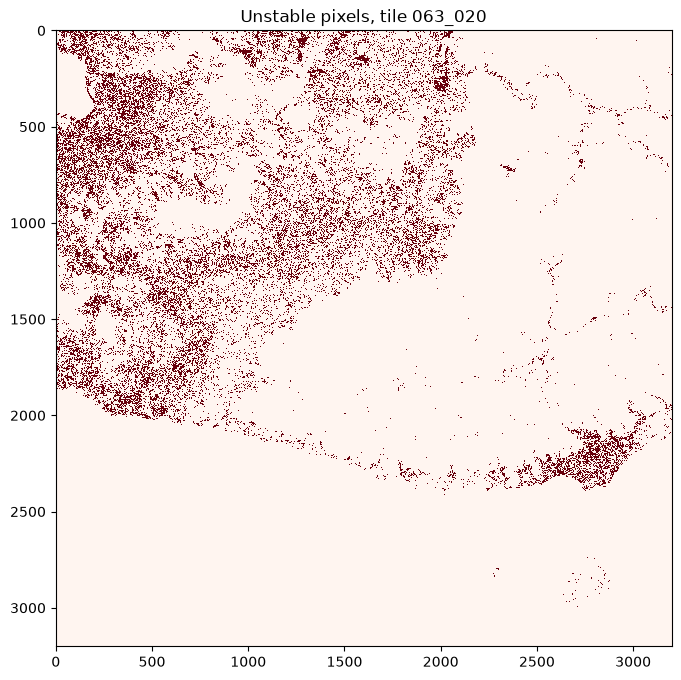

In [20]:
# Map of unstable pixels per tile to find hotspots
fig, axes = plt.subplots(1, len(TILES), figsize=(8 * len(TILES), 8), squeeze=False)
for ax, (tile, flags) in zip(axes[0], flags_by_tile.items()):
    ax.imshow(flags["any"], cmap="Reds", interpolation="nearest")
    ax.set_title(f"Unstable pixels, tile {tile[0]:03}_{tile[1]:03}")
plt.show()

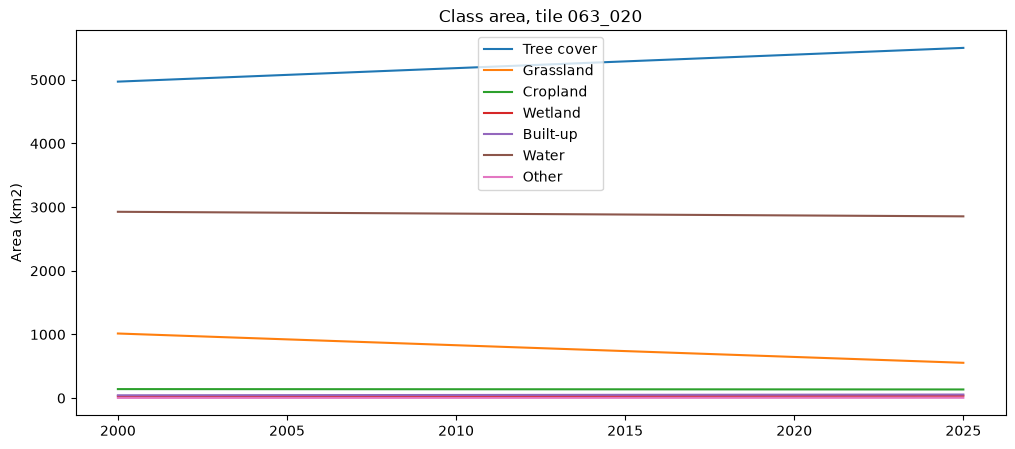

In [21]:
# Class area time series. Look for jumps that coincide with Landsat sensor changes or GeoMAD observation counts.
for tile, areas in areas_by_tile.items():
    ax = areas.plot(figsize=(12, 5), title=f"Class area, tile {tile[0]:03}_{tile[1]:03}", ylabel="Area (km2)")